In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vivekmettu/wikitext2-data/test.txt
/kaggle/input/datasets/vivekmettu/wikitext2-data/train.txt
/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv
/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv


In [2]:
%%writefile data.py
import os
import pickle
from collections import Counter
from typing import Tuple, List, Optional

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# 1. Simple Vocabulary

class Vocabulary:
    PAD, UNK, BOS, EOS = "<pad>", "<unk>", "<bos>", "<eos>"

    def __init__(self):
        self.token2idx = {}
        self.idx2token = []

    def build(self, texts: List[str], max_size: int = 10_000, min_freq: int = 2):
        counter = Counter()
        for text in texts:
            counter.update(text.lower().split())

        for tok in [self.PAD, self.UNK, self.BOS, self.EOS]:
            self._add(tok)

        for tok, freq in counter.most_common(max_size - 4):
            if freq < min_freq:
                break
            self._add(tok)

    def _add(self, token: str):
        if token not in self.token2idx:
            self.token2idx[token] = len(self.idx2token)
            self.idx2token.append(token)

    def encode(self, text: str, add_special: bool = False) -> List[int]:
        ids = [self.token2idx.get(t, self.token2idx[self.UNK]) for t in text.lower().split()]
        if add_special:
            ids = [self.token2idx[self.BOS]] + ids + [self.token2idx[self.EOS]]
        return ids

    def decode(self, ids: List[int]) -> str:
        return " ".join(self.idx2token[i] for i in ids)

    @property
    def pad_idx(self) -> int: return self.token2idx[self.PAD]

    @property
    def bos_idx(self) -> int: return self.token2idx[self.BOS]

    @property
    def eos_idx(self) -> int: return self.token2idx[self.EOS]

    def __len__(self) -> int: return len(self.idx2token)

    def save(self, path: str):
        with open(path, "wb") as f: pickle.dump(self, f)

    @staticmethod
    def load(path: str) -> "Vocabulary":
        with open(path, "rb") as f: return pickle.load(f)


# 2. WikiText-2 Dataset (Language Modeling)

class WikiText2Dataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int = 128):
        self.seq_len = seq_len
        n = (len(token_ids) - 1) // seq_len * seq_len
        self.data = torch.tensor(token_ids[:n + 1], dtype=torch.long)

    def __len__(self) -> int:
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        start = idx * self.seq_len
        src = self.data[start : start + self.seq_len]
        tgt = self.data[start + 1 : start + self.seq_len + 1]
        return src, tgt

def load_wikitext2(
    data_dir: str = "./data/wikitext2",
    seq_len: int = 128,
    vocab_max_size: int = 10_000,
    batch_size: int = 64,
    num_workers: int = 0,
) -> Tuple[DataLoader, DataLoader, DataLoader, Vocabulary]:
    os.makedirs(data_dir, exist_ok=True)
    vocab_path = os.path.join(data_dir, "vocab.pkl")

    try:
        from datasets import load_dataset
        print("Downloading WikiText-2 via Hugging Face …")
        ds = load_dataset("wikitext", "wikitext-2-raw-v1")
        train_text = " ".join(ds["train"]["text"])
        val_text   = " ".join(ds["validation"]["text"])
        test_text  = " ".join(ds["test"]["text"])
    except ImportError:
        print("[WARN] datasets not found — using synthetic corpus for smoke test.")
        train_text = " ".join(["the cat sat on the mat"] * 5000)
        val_text   = " ".join(["a dog ran in the park"] * 500)
        test_text  = " ".join(["birds fly over the hill"] * 500)

    if os.path.exists(vocab_path):
        print("Loading cached vocabulary …")
        vocab = Vocabulary.load(vocab_path)
    else:
        print("Building vocabulary …")
        vocab = Vocabulary()
        vocab.build([train_text], max_size=vocab_max_size, min_freq=2)
        vocab.save(vocab_path)
    print(f"Vocabulary size: {len(vocab):,}")

    def tokenize(text: str) -> List[int]:
        return vocab.encode(text, add_special=False)

    splits = {}
    for name, raw in [("train", train_text), ("val", val_text), ("test", test_text)]:
        cache = os.path.join(data_dir, f"{name}_ids.pkl")
        if os.path.exists(cache):
            with open(cache, "rb") as f: splits[name] = pickle.load(f)
        else:
            splits[name] = tokenize(raw)
            with open(cache, "wb") as f: pickle.dump(splits[name], f)

    train_ds = WikiText2Dataset(splits["train"], seq_len)
    val_ds   = WikiText2Dataset(splits["val"],   seq_len)
    test_ds  = WikiText2Dataset(splits["test"],  seq_len)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"WikiText-2 — train: {len(train_ds):,} | val: {len(val_ds):,} | test: {len(test_ds):,}")
    return train_dl, val_dl, test_dl, vocab


# 3. AG News Dataset (4-class Classification)

AGNEWS_LABELS = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

class AGNewsDataset(Dataset):
    def __init__(self, samples: List[Tuple[int, List[int]]], max_len: int = 128):
        self.samples = samples
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        label, ids = self.samples[idx]
        ids = ids[: self.max_len]
        return torch.tensor(ids, dtype=torch.long), label

def agnews_collate_fn(pad_idx: int):
    def collate(batch):
        texts, labels = zip(*batch)
        padded = pad_sequence(texts, batch_first=True, padding_value=pad_idx)
        return padded, torch.tensor(labels, dtype=torch.long)
    return collate

def load_agnews(
    vocab: Vocabulary,
    data_dir: str = "./data/agnews",
    max_len: int = 128,
    batch_size: int = 64,
    num_workers: int = 0,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    os.makedirs(data_dir, exist_ok=True)

    def _process_split(hf_split) -> List[Tuple[int, List[int]]]:
        samples = []
        for row in hf_split:
            ids = vocab.encode(row["text"], add_special=False)
            if len(ids) == 0: continue
            # Hugging Face labels are already 0-indexed!
            samples.append((row["label"], ids))  
        return samples

    cache_train = os.path.join(data_dir, "train.pkl")
    cache_test  = os.path.join(data_dir, "test.pkl")

    if os.path.exists(cache_train) and os.path.exists(cache_test):
        print("Loading cached AG News splits …")
        with open(cache_train, "rb") as f: train_samples = pickle.load(f)
        with open(cache_test,  "rb") as f: test_samples  = pickle.load(f)
    else:
        try:
            from datasets import load_dataset
            print("Downloading AG News via Hugging Face …")
            ds = load_dataset("ag_news")
            train_samples = _process_split(ds["train"])
            test_samples  = _process_split(ds["test"])
            with open(cache_train, "wb") as f: pickle.dump(train_samples, f)
            with open(cache_test,  "wb") as f: pickle.dump(test_samples,  f)
        except ImportError:
            print("[WARN] datasets not found — using synthetic AG News for smoke test.")
            import random
            random.seed(42)
            train_samples = [(random.randint(0, 3), vocab.encode("sports team wins game championship", False)) for _ in range(2000)]
            test_samples  = [(random.randint(0, 3), vocab.encode("science technology research study",   False)) for _ in range(400)]

    # 10% of train → validation
    split = int(0.9 * len(train_samples))
    val_samples = train_samples[split:]
    train_samples = train_samples[:split]

    collate = agnews_collate_fn(vocab.pad_idx)

    train_ds = AGNewsDataset(train_samples, max_len)
    val_ds   = AGNewsDataset(val_samples,   max_len)
    test_ds  = AGNewsDataset(test_samples,  max_len)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate, num_workers=num_workers, pin_memory=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=num_workers, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=num_workers, pin_memory=True)

    print(f"AG News — train: {len(train_ds):,} | val: {len(val_ds):,} | test: {len(test_ds):,}")
    return train_dl, val_dl, test_dl

Writing data.py


In [3]:
%%writefile model.py
"""
model.py — Transformer Encoder-Decoder from Scratch
Components: Embedding, Multi-Head Attention, Feed-Forward, Layer Norm,
            Positional Encoding, Encoder, Decoder, Classifier Head.
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


# 1. Positional Encoding

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_seq_length: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, T, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, : x.size(1)])


# 2. Multi-Head Attention

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention with separate Q, K, V projections.
    W_q and W_v are kept as plain nn.Linear so LoRA can wrap them.
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.scale = math.sqrt(self.d_k)

        # Named individually so LoRA can target W_q and W_v by name
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.attn_dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)  # (B, H, T, d_k)

    def _combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, H, T, d_k = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, self.d_model)

    def forward(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        Q = self._split_heads(self.W_q(Q))
        K = self._split_heads(self.W_k(K))
        V = self._split_heads(self.W_v(V))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = self.attn_dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(attn_weights, V)
        return self.W_o(self._combine_heads(out))


# 3. Position-Wise Feed-Forward Network

class PositionWiseFeedForward(nn.Module):
    """Two-layer FFN with GELU activation (slightly better than ReLU in practice)."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.dropout(self.activation(self.fc1(x))))


# 4. Encoder Layer

class EncoderLayer(nn.Module):
    """Pre-LayerNorm encoder block (more stable training than post-LN)."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        # Pre-LN: normalize before sublayer
        x = x + self.dropout(self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), mask))
        x = x + self.dropout(self.feed_forward(self.norm2(x)))
        return x

# 5. Decoder Layer

class DecoderLayer(nn.Module):
    """Pre-LayerNorm decoder block with masked self-attention + cross-attention."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        enc_output: torch.Tensor,
        src_mask: torch.Tensor = None,
        tgt_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        n1 = self.norm1(x)
        x = x + self.dropout(self.self_attn(n1, n1, n1, tgt_mask))
        n2 = self.norm2(x)
        x = x + self.dropout(self.cross_attn(n2, enc_output, enc_output, src_mask))
        x = x + self.dropout(self.feed_forward(self.norm3(x)))
        return x


# 6. Full Transformer (Encoder + Decoder)

class Transformer(nn.Module):
    """
    Full encoder-decoder transformer for language model pretraining.
    Encoder output is reused during fine-tuning (classification).
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        num_heads: int = 8,
        num_layers: int = 4,
        d_ff: int = 1024,
        max_seq_length: int = 128,
        dropout: float = 0.1,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.num_layers = num_layers

        self.encoder_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.decoder_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_length, dropout)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )

        self.encoder_norm = nn.LayerNorm(d_model)
        self.decoder_norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size)

        # Tie weights: output projection shares encoder embedding matrix
        self.fc_out.weight = self.encoder_embedding.weight

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if "embedding" in name:
                nn.init.normal_(p, mean=0.0, std=self.d_model ** -0.5)
            elif p.dim() > 1:
                nn.init.xavier_uniform_(p)
            elif "bias" in name:
                nn.init.zeros_(p)

    # Mask helpers

    def make_src_mask(self, src: torch.Tensor) -> torch.Tensor:
        """Padding mask: (B, 1, 1, T)"""
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt: torch.Tensor) -> torch.Tensor:
        """Combined padding + causal mask: (B, 1, T, T)"""
        B, T = tgt.shape
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)         # (B,1,1,T)
        causal = torch.tril(torch.ones(T, T, device=tgt.device)).bool()    # (T,T)
        return pad_mask & causal.unsqueeze(0).unsqueeze(0)                  # (B,1,T,T)

    # Forward passes

    def encode(self, src: torch.Tensor, src_mask: torch.Tensor = None) -> torch.Tensor:
        x = self.pos_encoding(self.encoder_embedding(src) * math.sqrt(self.d_model))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return self.encoder_norm(x)  # (B, T, d_model)

    def decode(
        self,
        tgt: torch.Tensor,
        enc_output: torch.Tensor,
        src_mask: torch.Tensor = None,
        tgt_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        x = self.pos_encoding(self.decoder_embedding(tgt) * math.sqrt(self.d_model))
        for layer in self.decoder_layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return self.decoder_norm(x)  # (B, T, d_model)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encode(src, src_mask)
        dec_out = self.decode(tgt, enc_out, src_mask, tgt_mask)
        return self.fc_out(dec_out)  # (B, T, vocab_size)


# 7. Classification Head (for AG News fine-tuning)

class TransformerClassifier(nn.Module):
    """
    Encoder-only classifier.
    Mean-pools encoder output over non-padding tokens → MLP head.
    Works for both full fine-tuning and LoRA (freeze_base controls encoder grad).
    """

    def __init__(
        self,
        transformer: Transformer,
        num_classes: int = 4,
        freeze_base: bool = False,
        clf_dropout: float = 0.1,
    ):
        super().__init__()
        self.transformer = transformer

        if freeze_base:
            for p in self.transformer.parameters():
                p.requires_grad_(False)

        d = transformer.d_model
        self.classifier = nn.Sequential(
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(clf_dropout),
            nn.Linear(d // 2, num_classes),
        )
        # Always init the head fresh
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        src_mask = self.transformer.make_src_mask(src)          # (B,1,1,T)
        enc = self.transformer.encode(src, src_mask)            # (B,T,d)

        # Mean pool over valid (non-pad) positions
        mask_f = src_mask.squeeze(1).squeeze(1).unsqueeze(-1).float()  # (B,T,1)
        pooled = (enc * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)  # (B,d)
        return self.classifier(pooled)                          # (B,num_classes)


# 8. Utilities

def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def build_transformer(vocab_size: int, cfg: dict) -> Transformer:
    return Transformer(
        vocab_size=vocab_size,
        d_model=cfg["d_model"],
        num_heads=cfg["num_heads"],
        num_layers=cfg["num_layers"],
        d_ff=cfg["d_ff"],
        max_seq_length=cfg["max_seq_length"],
        dropout=cfg["dropout"],
        pad_idx=cfg.get("pad_idx", 0),
    )


Writing model.py


In [4]:
%%writefile train_utils.py
"""
train_utils.py — Shared Training Infrastructure
- LR schedulers (warmup + cosine decay)
- Label smoothing loss
- Gradient clipping
- Accuracy metrics
- Checkpoint save/load
- Early stopping
"""

import os
import math
import time
from typing import Optional, Dict, Any, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR


# 1. Label Smoothing Cross-Entropy (for pretraining)

class LabelSmoothingLoss(nn.Module):
    """
    Cross-entropy with label smoothing. Helps prevent overconfident
    predictions during pretraining.

    Args:
        vocab_size  : number of classes
        pad_idx     : index to ignore (padding)
        smoothing   : epsilon (0.0 = standard CE, 0.1 = recommended)
    """

    def __init__(self, vocab_size: int, pad_idx: int = 0, smoothing: float = 0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_idx = pad_idx
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (B*T, vocab_size), targets: (B*T,)
        B_T = targets.size(0)
        log_probs = F.log_softmax(logits, dim=-1)

        # Smooth target distribution
        smooth_val = self.smoothing / (self.vocab_size - 2)
        with torch.no_grad():
            dist = torch.full_like(log_probs, smooth_val)
            dist.scatter_(1, targets.unsqueeze(1), self.confidence)
            dist[:, self.pad_idx] = 0.0                # don't penalize pad predictions

        # Mask out padding positions
        mask = targets != self.pad_idx
        loss = (-dist * log_probs).sum(dim=-1)
        return loss[mask].mean()


# 2. LR Scheduler: Warmup + Cosine Decay

def get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    min_lr_ratio: float = 0.1,
) -> LambdaLR:
    """
    Linear warmup from 0 → peak LR over `num_warmup_steps`,
    then cosine decay from peak → min_lr_ratio * peak.
    """
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            return float(current_step) / max(1, num_warmup_steps)
        progress = float(current_step - num_warmup_steps) / max(
            1, num_training_steps - num_warmup_steps
        )
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return max(min_lr_ratio, cosine)

    return LambdaLR(optimizer, lr_lambda)


def get_linear_schedule_with_warmup(optimizer, num_warmup_steps: int, num_training_steps: int) -> LambdaLR:
    def lr_lambda(step):
        if step < num_warmup_steps:
            return step / max(1, num_warmup_steps)
        return max(0.0, (num_training_steps - step) / max(1, num_training_steps - num_warmup_steps))
    return LambdaLR(optimizer, lr_lambda)


# 3. Accuracy Metrics

def compute_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    """Top-1 accuracy for classification."""
    preds = logits.argmax(dim=-1)
    return (preds == labels).float().mean().item()


def compute_perplexity(loss: float) -> float:
    """Perplexity from cross-entropy loss."""
    return math.exp(min(loss, 20))  # cap at exp(20) to avoid overflow


# 4. Checkpoint Management

def save_checkpoint(
    model: nn.Module,
    optimizer,
    scheduler,
    epoch: int,
    step: int,
    loss: float,
    path: str,
    extra: Optional[Dict[str, Any]] = None,
):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "epoch": epoch,
        "step": step,
        "loss": loss,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    print(f"  [ckpt] saved → {path}")


def load_checkpoint(
    model: nn.Module,
    path: str,
    optimizer=None,
    scheduler=None,
    device: str = "cpu",
    strict: bool = True,
) -> Dict[str, Any]:
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"], strict=strict)
    if optimizer and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler and ckpt.get("scheduler_state_dict"):
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"  [ckpt] loaded ← {path}  (epoch {ckpt.get('epoch', '?')}, loss {ckpt.get('loss', 0):.4f})")
    return ckpt


# 5. Early Stopping

class EarlyStopping:
    """
    Stops training if validation metric doesn't improve for `patience` epochs.
    Tracks best model state in memory.
    """

    def __init__(self, patience: int = 5, min_delta: float = 1e-4, mode: str = "min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = float("inf") if mode == "min" else float("-inf")
        self.counter = 0
        self.best_state: Optional[Dict] = None

    def step(self, metric: float, model: nn.Module) -> bool:
        improved = (
            metric < self.best - self.min_delta if self.mode == "min"
            else metric > self.best + self.min_delta
        )
        if improved:
            self.best = metric
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore_best(self, model: nn.Module):
        if self.best_state:
            model.load_state_dict(self.best_state)



# 6. AverageMeter for running stats

class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = self.avg = self.sum = self.count = 0.0

    def update(self, val: float, n: int = 1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


# 7. Build AdamW Optimizer with parameter groups

def build_optimizer(
    model: nn.Module,
    lr: float,
    weight_decay: float = 0.01,
    betas: tuple = (0.9, 0.98),
    eps: float = 1e-8,
) -> AdamW:
    """
    Separates parameters into two groups:
    - weight matrices (with weight decay)
    - biases and layer norm params (no decay)
    """
    no_decay = {"bias", "norm", "layernorm"}
    decay_params, no_decay_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(nd in name.lower() for nd in no_decay):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    param_groups = [
        {"params": decay_params,    "weight_decay": weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]
    return AdamW(param_groups, lr=lr, betas=betas, eps=eps)


# 8. Gradient norm clipping helper


def clip_gradients(model: nn.Module, max_norm: float = 1.0) -> float:
    """Clips gradient norm, returns the pre-clip global norm."""
    return nn.utils.clip_grad_norm_(model.parameters(), max_norm).item()



# 9. Timing context manager


class Timer:
    def __enter__(self):
        self.start = time.time()
        return self
    def __exit__(self, *_):
        self.elapsed = time.time() - self.start
    def __str__(self):
        return f"{self.elapsed:.1f}s"


Writing train_utils.py


In [5]:
%%writefile lora.py
"""
lora.py — Low-Rank Adaptation (LoRA)
Injects trainable low-rank matrices (A, B) into W_q and W_v of every
attention layer. Base weights are frozen; only A and B are trained.

Reference: Hu et al., "LoRA: Low-Rank Adaptation of Large Language Models", 2021.
"""

import math
import torch
import torch.nn as nn
from model import MultiHeadAttention, Transformer, TransformerClassifier


# 1. LoRA Linear Layer


class LoRALinear(nn.Module):
    """
    Wraps a frozen nn.Linear with a trainable low-rank bypass:
        output = W_frozen(x) + (B @ A)(x) * (alpha / r)

    Args:
        base_linear : the original nn.Linear to wrap (will be frozen)
        r           : rank of the low-rank decomposition
        alpha       : scaling factor (LoRA paper: alpha / r controls magnitude)
        dropout     : dropout on the low-rank path
    """

    def __init__(
        self,
        base_linear: nn.Linear,
        r: int = 8,
        alpha: float = 16.0,
        dropout: float = 0.0,
    ):
        super().__init__()
        assert r > 0
        in_features = base_linear.in_features
        out_features = base_linear.out_features

        # Freeze base weight
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad_(False)

        self.r = r
        self.scaling = alpha / r

        # Trainable low-rank matrices
        self.lora_A = nn.Parameter(torch.empty(r, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))

        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Kaiming init for A (B starts at zero → zero init for LoRA path)
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.base(x)
        lora_out = self.lora_dropout(x) @ self.lora_A.T @ self.lora_B.T
        return base_out + lora_out * self.scaling

    def extra_repr(self) -> str:
        return (
            f"in={self.base.in_features}, out={self.base.out_features}, "
            f"r={self.r}, scaling={self.scaling:.3f}"
        )



# 2. Inject LoRA into Attention Layers


def inject_lora_into_attention(
    attn: MultiHeadAttention,
    r: int = 8,
    alpha: float = 16.0,
    lora_dropout: float = 0.0,
) -> MultiHeadAttention:
    """
    Replaces W_q and W_v in a MultiHeadAttention module with LoRALinear wrappers.
    W_k and W_o remain frozen (standard LoRA practice).
    """
    attn.W_q = LoRALinear(attn.W_q, r=r, alpha=alpha, dropout=lora_dropout)
    attn.W_v = LoRALinear(attn.W_v, r=r, alpha=alpha, dropout=lora_dropout)
    return attn


def apply_lora_to_transformer(
    transformer: Transformer,
    r: int = 8,
    alpha: float = 16.0,
    lora_dropout: float = 0.0,
) -> Transformer:
    """
    Freezes all base weights and injects LoRA into every attention layer
    (both encoder self-attention and decoder self/cross-attention).

    Returns the same transformer object, modified in-place.
    """
    # Freeze everything first
    for p in transformer.parameters():
        p.requires_grad_(False)

    # Inject into encoder layers
    for layer in transformer.encoder_layers:
        inject_lora_into_attention(layer.self_attn, r, alpha, lora_dropout)

    # Inject into decoder layers (both self-attn and cross-attn)
    for layer in transformer.decoder_layers:
        inject_lora_into_attention(layer.self_attn, r, alpha, lora_dropout)
        inject_lora_into_attention(layer.cross_attn, r, alpha, lora_dropout)

    return transformer



# 3. Build LoRA Classifier


def build_lora_classifier(
    transformer: Transformer,
    num_classes: int = 4,
    r: int = 8,
    alpha: float = 16.0,
    lora_dropout: float = 0.05,
    clf_dropout: float = 0.1,
) -> TransformerClassifier:
    """
    Loads a pretrained transformer, injects LoRA, wraps with classifier head.
    Only LoRA matrices (A, B) and classifier head weights are trainable.
    """
    # Apply LoRA (freezes base, injects trainable A/B)
    apply_lora_to_transformer(transformer, r=r, alpha=alpha, lora_dropout=lora_dropout)

    # Build classifier — freeze_base=False because transformer is already frozen
    # and we want the classifier head to be trainable
    clf = TransformerClassifier(
        transformer,
        num_classes=num_classes,
        freeze_base=False,  # base already frozen by apply_lora_to_transformer
        clf_dropout=clf_dropout,
    )
    return clf



# 4. Utilities

def count_lora_parameters(model: nn.Module) -> dict:
    """Returns trainable vs total parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "total": total,
        "trainable": trainable,
        "frozen": total - trainable,
        "trainable_pct": 100.0 * trainable / total,
    }


def get_lora_state_dict(model: nn.Module) -> dict:
    """Returns only the trainable (LoRA + head) parameters — for compact saving."""
    return {k: v for k, v in model.state_dict().items() if "lora_" in k or "classifier" in k}


Writing lora.py


Using device: cuda

--- Loading Datasets (Hugging Face) ---


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

[LoRA FT] Epoch 2 Val Acc: 79.66%


[LoRA FT] Epoch 3/4:   0%|          | 0/1688 [00:00<?, ?it/s]

[LoRA FT] Epoch 3 Val Acc: 81.69%


[LoRA FT] Epoch 4/4:   0%|          | 0/1688 [00:00<?, ?it/s]

[LoRA FT] Epoch 4 Val Acc: 82.93%

=== FINAL RESULTS & COMPUTE SUMMARY ===

1. Classification Accuracy:
   -> Full Fine-Tuning: 89.00%
   -> LoRA Fine-Tuning: 82.93%

2. Compute Resources & Time:
   -> Full Fine-Tuning:
      - Trainable Params: 15,089,948 (100%)
      - Total Train Time: 5.55 minutes
   -> LoRA Fine-Tuning:
      - Trainable Params: 131,716 (0.87%)
      - Total Train Time: 4.57 minutes

   >> CONCLUSION: LoRA saved 0.98 minutes of compute time
      while updating ~99% fewer parameters!



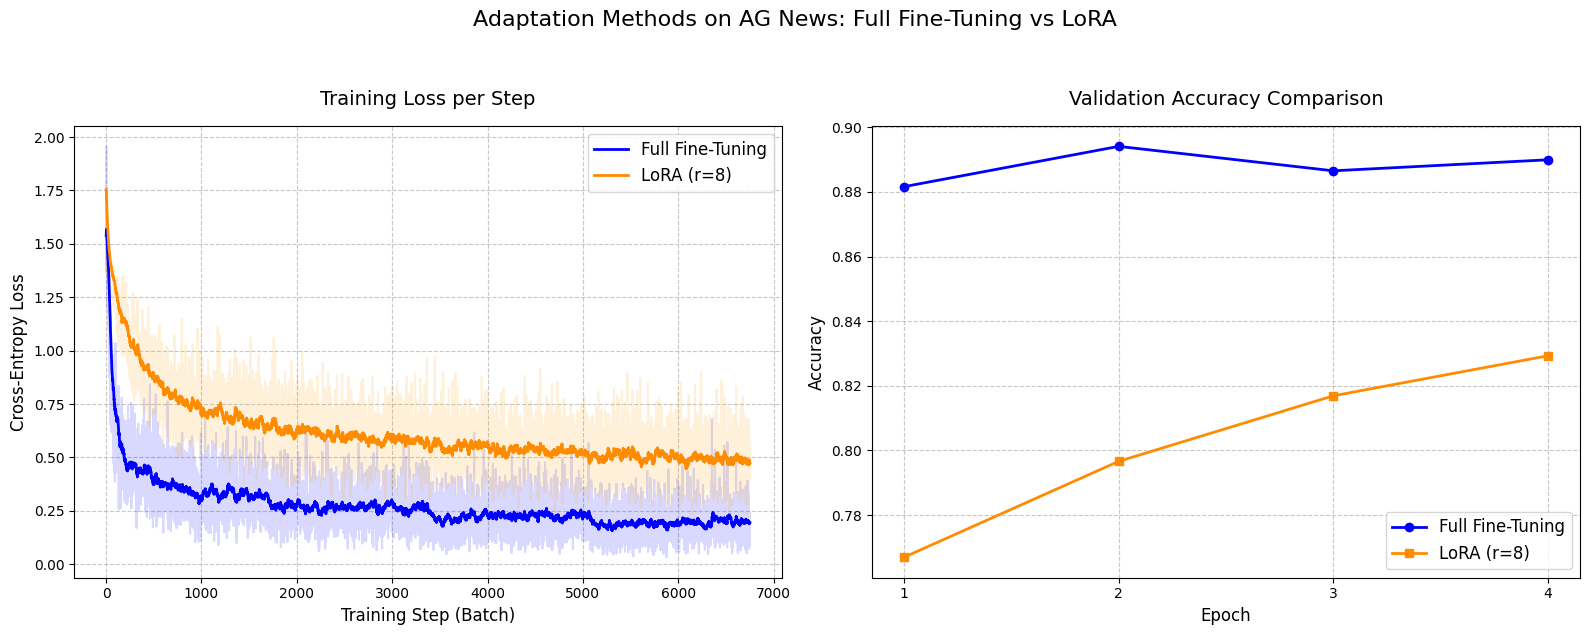

In [6]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Import from your modules
from data import load_wikitext2, load_agnews
from model import build_transformer, TransformerClassifier
from lora import build_lora_classifier, count_lora_parameters
from train_utils import build_optimizer, compute_accuracy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")


# 1. Configuration & Data Loading

cfg = {
    "d_model": 256,
    "num_heads": 8,
    "num_layers": 4,
    "d_ff": 1024,
    "max_seq_length": 128,
    "dropout": 0.1
}

print("--- Loading Datasets (Hugging Face) ---")
wt_train, wt_val, wt_test, vocab = load_wikitext2(vocab_max_size=15000, batch_size=64)
cfg["pad_idx"] = vocab.pad_idx
ag_train, ag_val, ag_test = load_agnews(vocab, batch_size=64)



# 2. Phase 1: Pretraining the Base Model

print("\n--- Phase 1: Pretraining Base Model (WikiText-2) ---")
base_transformer = build_transformer(len(vocab), cfg).to(device)
optimizer = build_optimizer(base_transformer, lr=3e-4)
criterion_pt = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

PRETRAIN_EPOCHS = 3
for epoch in range(PRETRAIN_EPOCHS):
    base_transformer.train()
    loop = tqdm(wt_train, desc=f"Pretrain Epoch {epoch+1}/{PRETRAIN_EPOCHS}")
    for src, tgt in loop:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        
        logits = base_transformer(src, tgt)
        loss = criterion_pt(logits.view(-1, logits.size(-1)), tgt.view(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base_transformer.parameters(), max_norm=1.0)
        optimizer.step()
        loop.set_postfix(loss=loss.item())

torch.save(base_transformer.state_dict(), "pretrained_base_real.pt")
print("Saved shared starting checkpoint: pretrained_base_real.pt")



# Fine-Tuning Helper Function 

def finetune_model(model, train_dl, val_dl, name, epochs=4):
    model = model.to(device)
    optimizer = build_optimizer(model, lr=5e-4)
    criterion = nn.CrossEntropyLoss()
    
    step_loss_history = []  
    val_acc_history = []
    
    for epoch in range(epochs):
        model.train()
        loop = tqdm(train_dl, desc=f"[{name}] Epoch {epoch+1}/{epochs}")
        for src, labels in loop:
            src, labels = src.to(device), labels.to(device)
            optimizer.zero_grad()
            
            logits = model(src)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            step_loss_history.append(loss.item()) 
            loop.set_postfix(loss=loss.item())
            
        model.eval()
        val_accs = []
        with torch.no_grad():
            for src, labels in val_dl:
                src, labels = src.to(device), labels.to(device)
                logits = model(src)
                acc = compute_accuracy(logits, labels)
                val_accs.append(acc)
        
        epoch_acc = sum(val_accs)/len(val_accs)
        val_acc_history.append(epoch_acc)
        print(f"[{name}] Epoch {epoch+1} Val Acc: {epoch_acc * 100:.2f}%")
        
    return step_loss_history, val_acc_history


# 3. Phase 2: Full Fine-Tuning

print("\n--- Phase 2: Full Fine-Tuning (AG News) ---")
full_ft_base = build_transformer(len(vocab), cfg)
full_ft_base.load_state_dict(torch.load("pretrained_base_real.pt"))

full_ft_model = TransformerClassifier(full_ft_base, num_classes=4, freeze_base=False)
full_ft_params = count_lora_parameters(full_ft_model)
print(f"-> Full FT Trainable Parameters: {full_ft_params['trainable']:,} ({full_ft_params['trainable_pct']:.2f}% of total)")

start_time_ff = time.time()  # <-- Start Full FT Timer
ff_losses, ff_accs = finetune_model(full_ft_model, ag_train, ag_val, "Full FT", epochs=4)
end_time_ff = time.time()    # <-- End Full FT Timer
total_time_ff = end_time_ff - start_time_ff



# 4. Phase 3: LoRA Fine-Tuning

print("\n--- Phase 3: LoRA Fine-Tuning (AG News) ---")
lora_base = build_transformer(len(vocab), cfg)
lora_base.load_state_dict(torch.load("pretrained_base_real.pt"))

lora_model = build_lora_classifier(lora_base, num_classes=4, r=8, alpha=16.0)
lora_params = count_lora_parameters(lora_model)
print(f"-> LoRA Trainable Parameters: {lora_params['trainable']:,} ({lora_params['trainable_pct']:.2f}% of total)")

start_time_lora = time.time()  # <-- Start LoRA Timer
lora_losses, lora_accs = finetune_model(lora_model, ag_train, ag_val, "LoRA FT", epochs=4)
end_time_lora = time.time()    # <-- End LoRA Timer
total_time_lora = end_time_lora - start_time_lora



# 5. Final Reporting & Step-Wise Plotting

print("\n" + "="*40)
print("=== FINAL RESULTS & COMPUTE SUMMARY ===")
print("="*40)

print("\n1. Classification Accuracy:")
print(f"   -> Full Fine-Tuning: {ff_accs[-1] * 100:.2f}%")
print(f"   -> LoRA Fine-Tuning: {lora_accs[-1] * 100:.2f}%")

print("\n2. Compute Resources & Time:")
print(f"   -> Full Fine-Tuning:")
print(f"      - Trainable Params: {full_ft_params['trainable']:,} (100%)")
print(f"      - Total Train Time: {total_time_ff / 60:.2f} minutes")
print(f"   -> LoRA Fine-Tuning:")
print(f"      - Trainable Params: {lora_params['trainable']:,} ({lora_params['trainable_pct']:.2f}%)")
print(f"      - Total Train Time: {total_time_lora / 60:.2f} minutes")

time_saved = total_time_ff - total_time_lora
print(f"\n   >> CONCLUSION: LoRA saved {time_saved / 60:.2f} minutes of compute time")
print(f"      while updating ~99% fewer parameters!")
print("="*40 + "\n")

# Smoothing function for the step-wise plot
def smooth_curve(points, factor=0.95):
    smoothed = []
    for point in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

ff_losses_smooth = smooth_curve(ff_losses)
lora_losses_smooth = smooth_curve(lora_losses)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training Loss (Step-wise)
steps = range(1, len(ff_losses) + 1)
ax1.plot(steps, ff_losses, color='blue', alpha=0.15)
ax1.plot(steps, lora_losses, color='orange', alpha=0.15)
ax1.plot(steps, ff_losses_smooth, color='blue', linewidth=2, label='Full Fine-Tuning')
ax1.plot(steps, lora_losses_smooth, color='darkorange', linewidth=2, label='LoRA (r=8)')

ax1.set_title('Training Loss per Step', fontsize=14, pad=15)
ax1.set_xlabel('Training Step (Batch)', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Validation Accuracy (Epoch-wise)
epochs_range = range(1, len(ff_accs) + 1)
ax2.plot(epochs_range, ff_accs, marker='o', linewidth=2, color='blue', label='Full Fine-Tuning')
ax2.plot(epochs_range, lora_accs, marker='s', linewidth=2, color='darkorange', label='LoRA (r=8)')

ax2.set_title('Validation Accuracy Comparison', fontsize=14, pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xticks(epochs_range)
ax2.legend(fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Adaptation Methods on AG News: Full Fine-Tuning vs LoRA', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [7]:
import torch
import torch.nn.functional as F

# AG News Label Mapping
AG_LABELS = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# 1. Text Generation Helper for Base Model
def generate_next_words(text, model, vocab, num_words=5):
    model.eval()
    # Tokenize input text
    tokens = vocab.encode(text, add_special=False)
    input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
    
    generated = tokens.copy()
    
    with torch.no_grad():
        for _ in range(num_words):
            # Base model outputs shape: (Batch, Seq_Len, Vocab_Size)
            logits = model(input_ids, input_ids)
            
            # Get the prediction for the very last token in the sequence
            next_token_logits = logits[0, -1, :]
            next_token_id = torch.argmax(next_token_logits).item()
            
            generated.append(next_token_id)
            # Update input for next iteration
            input_ids = torch.tensor([generated], dtype=torch.long).to(device)
            
    return vocab.decode(generated)


# 2. Classification Helper for FT / LoRA Models
def predict_category(text, model, vocab):
    model.eval()
    tokens = vocab.encode(text, add_special=False)
    
    # Handle words not in vocab (if any) to prevent empty tensors
    if len(tokens) == 0:
        return "Unknown", 0.0
        
    input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
    
    with torch.no_grad():
        # Classifier models output shape: (Batch, Num_Classes)
        logits = model(input_ids)
        probs = F.softmax(logits, dim=-1)
        
        predicted_class = torch.argmax(probs, dim=-1).item()
        confidence = probs[0, predicted_class].item()
        
    return AG_LABELS[predicted_class], confidence



# 3. Testing

test_headlines = [
    "Wall street surges as tech stocks rally in the final quarter.",
    "The quarterback threw a game winning touchdown in the fourth quarter.",
    "Scientists discover a new exoplanet orbiting a distant star.",
    "Peace talks continue between the two nations in Geneva."
]

print("="*60)
print("INFERENCE COMPARISON: BASE vs FULL FT vs LORA")
print("="*60)

for idx, headline in enumerate(test_headlines):
    print(f"\nHeadline {idx+1}: '{headline}'\n")
    
    # 1. Base Model (Next Word Prediction)
    # Note: We use base_transformer which is still in memory
    try:
        continuation = generate_next_words(headline, base_transformer, vocab, num_words=6)
        print(f"   [Base Pretrained] Continuation : {continuation} ...")
    except Exception as e:
         print(f"   [Base Pretrained] Error generating: {e}")
            
    # 2. Full Fine-Tuning Model (Classification)
    ff_pred, ff_conf = predict_category(headline, full_ft_model, vocab)
    print(f"   [Full Fine-Tuned] Prediction   : {ff_pred} (Confidence: {ff_conf*100:.1f}%)")
    
    # 3. LoRA Model (Classification)
    lora_pred, lora_conf = predict_category(headline, lora_model, vocab)
    print(f"   [LoRA Fine-Tuned] Prediction   : {lora_pred} (Confidence: {lora_conf*100:.1f}%)")
    print("-" * 60)

INFERENCE COMPARISON: BASE vs FULL FT vs LORA

Headline 1: 'Wall street surges as tech stocks rally in the final quarter.'

   [Base Pretrained] Continuation : wall street <unk> as tech <unk> rally in the final <unk> <unk> <unk> <unk> <unk> <unk> <unk> ...
   [Full Fine-Tuned] Prediction   : Business (Confidence: 78.6%)
   [LoRA Fine-Tuned] Prediction   : Business (Confidence: 50.6%)
------------------------------------------------------------

Headline 2: 'The quarterback threw a game winning touchdown in the fourth quarter.'

   [Base Pretrained] Continuation : the quarterback threw a game winning touchdown in the fourth <unk> <unk> <unk> <unk> <unk> <unk> <unk> ...
   [Full Fine-Tuned] Prediction   : Sports (Confidence: 99.9%)
   [LoRA Fine-Tuned] Prediction   : Sports (Confidence: 98.0%)
------------------------------------------------------------

Headline 3: 'Scientists discover a new exoplanet orbiting a distant star.'

   [Base Pretrained] Continuation : scientists discover a n